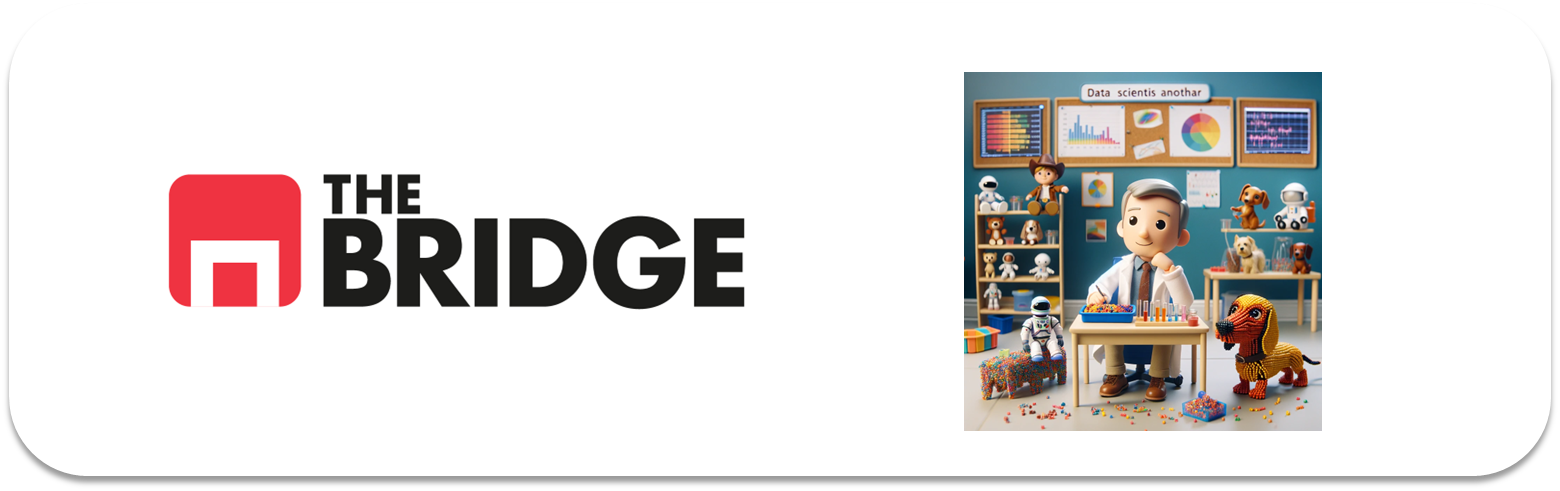

## PRACTICA OBLIGATORIA: ANÁLISIS UNIVARIANTE

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook. Te dejo una que vas a necesitar sí o sí

In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from bootcampviztools import *

### #1 Preparación


### #1.1


Carga en un dataframe los datos del titanic a partir de un dataset de seaborn. Para ello:

* ejecuta ```python sns.get_dataset_names()```
* localiza el nombre que puede ser el adecuado para el ejercicio
* Asigna la salida de ```sns.load_dataset(<nombre_del_dataset>)``` a una variable "df_titanic"

In [2]:
sns.get_dataset_names()
df_titanic = sns.load_dataset("titanic")


### #1.2

Muestra una porción del dataset ("df_titanic") y su info general. ¿Hay nulos?

In [3]:
df_titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df_titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


### #1.3

Obtén el porcentaje de nulos y decide que hacer con las columnas con nulos y ejecútalo. Además deshazte de la columna "parch" que no la emplearemos.

In [5]:
df_titanic.isnull().mean() *100

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64

In [6]:
df_titanic.drop(["parch","deck"], axis=1, inplace=True) # Eliminamos la columna deck, que tiene un gran porcentaje de nulos
df_titanic

,survived,pclass,sex,age,sibsp,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,8.0500,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,13.0000,S,Second,man,True,Southampton,no,True
887,1,1,female,19.0,0,30.0000,S,First,woman,False,Southampton,yes,True
888,0,3,female,NaN,1,23.4500,S,Third,woman,False,Southampton,no,False
889,1,1,male,26.0,0,30.0000,C,First,man,True,Cherbourg,yes,True


### #1.4
Sobre el dataset "limpio". Rellena la tabla de descripción (muy breve) de lo que es cada columna en función de su nombre y los valores. Para ayudarte:
* Se trata del dataset que reune lo más parecido a un manifiesto de supervivientes y fallecidos en el viaje.
* sibsp: Es el numero de familiares que viajan con la persona indicada en el manifiesto (lista de pasajeros)
* embarked: Es la incial de la letra de la ciudad donde embarcó la persona.




| Columna/Variable | Descripción |
| ---------------- | ----------- |
| survived   | Si ha sobrevivido o no (0 o 1) |
| pcclass   | La clase del billete (int)|
| sex | hombre o mujer|
| age | edad (float)|
| sibsp | numero de familiares que viajan con la persona (int)|
| fare | precio del billete (float)|
| embarked | letra inicial de la ciudad donde embarco la persona |
| class | clase del billete (str)|
| who | hombre o mujer (str) |
| adult_male | si era hombre (bool) |
|embark_town | nombre entero de la ciudad donde embarco |
| alive | si sobrevivio (str) |
| alone | si viajaba solo |




### #1.5

Busca en internet las tres ciudades que visitó el Titanic antes de poner rumbo a su destino y llegar a alta mar. Cambia las iniciales por esos valores.

In [8]:
df_titanic["embarked"] = df_titanic["embarked"].replace({"S": "Southampton",
                            "C": "Cherbourg",
                            "Q": "Queenstown"})

df_titanic

,survived,pclass,sex,age,sibsp,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,7.2500,Southampton,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,71.2833,Cherbourg,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,7.9250,Southampton,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,53.1000,Southampton,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,8.0500,Southampton,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,13.0000,Southampton,Second,man,True,Southampton,no,True
887,1,1,female,19.0,0,30.0000,Southampton,First,woman,False,Southampton,yes,True
888,0,3,female,NaN,1,23.4500,Southampton,Third,woman,False,Southampton,no,False
889,1,1,male,26.0,0,30.0000,Cherbourg,First,man,True,Cherbourg,yes,True


In [10]:
df_titanic.drop("embark_town", axis=1, inplace=True)
df_titanic

,survived,pclass,sex,age,sibsp,fare,embarked,class,who,adult_male,alive,alone
0,0,3,male,22.0,1,7.2500,Southampton,Third,man,True,no,False
1,1,1,female,38.0,1,71.2833,Cherbourg,First,woman,False,yes,False
2,1,3,female,26.0,0,7.9250,Southampton,Third,woman,False,yes,True
3,1,1,female,35.0,1,53.1000,Southampton,First,woman,False,yes,False
4,0,3,male,35.0,0,8.0500,Southampton,Third,man,True,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,13.0000,Southampton,Second,man,True,no,True
887,1,1,female,19.0,0,30.0000,Southampton,First,woman,False,yes,True
888,0,3,female,NaN,1,23.4500,Southampton,Third,woman,False,no,False
889,1,1,male,26.0,0,30.0000,Cherbourg,First,man,True,yes,True


In [33]:
df_titanic["survived"] = df_titanic["survived"].replace({0: "False", 1: "True"})
df_titanic

,survived,pclass,sex,age,sibsp,fare,embarked,class,who,adult_male,alive,alone
0,False,3,male,22.0,1,7.2500,Southampton,Third,man,True,no,False
1,True,1,female,38.0,1,71.2833,Cherbourg,First,woman,False,yes,False
2,True,3,female,26.0,0,7.9250,Southampton,Third,woman,False,yes,True
3,True,1,female,35.0,1,53.1000,Southampton,First,woman,False,yes,False
4,False,3,male,35.0,0,8.0500,Southampton,Third,man,True,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,2,male,27.0,0,13.0000,Southampton,Second,man,True,no,True
887,True,1,female,19.0,0,30.0000,Southampton,First,woman,False,yes,True
888,False,3,female,NaN,1,23.4500,Southampton,Third,woman,False,no,False
889,True,1,male,26.0,0,30.0000,Cherbourg,First,man,True,yes,True


In [57]:
df_titanic["alone"] = df_titanic["alone"].replace({True: "True", False: "False"})

In [65]:
df_titanic

,survived,pclass,sex,age,sibsp,fare,embarked,class,who,adult_male,alive,alone
0,False,3,male,22.0,1,7.2500,Southampton,Third,man,True,no,False
1,True,1,female,38.0,1,71.2833,Cherbourg,First,woman,False,yes,False
2,True,3,female,26.0,0,7.9250,Southampton,Third,woman,False,yes,True
3,True,1,female,35.0,1,53.1000,Southampton,First,woman,False,yes,False
4,False,3,male,35.0,0,8.0500,Southampton,Third,man,True,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,2,male,27.0,0,13.0000,Southampton,Second,man,True,no,True
887,True,1,female,19.0,0,30.0000,Southampton,First,woman,False,yes,True
888,False,3,female,NaN,1,23.4500,Southampton,Third,woman,False,no,False
889,True,1,male,26.0,0,30.0000,Cherbourg,First,man,True,yes,True


### #2 Análisis

Sabiendo que el objetivo de nuestro análisis es hacer un estudio de la superviviencia y mortalidad en el viaje... Haz un análisis univariante completo y ordenado de las siguientes variables:
["survived","who","age","fare","class","embarked","alone"]
Nota: Si quieres añadir más, perfecto.

Separa el análisis en categóricas (incluyendo binarias) y numéricas. Muestra valores, gráficas y conclusiones/observaciones (2 o 3 por variable)

### #2.1 Categóricas

In [ ]:
# survived, who, class, embarked, alone

In [71]:
def card_tipo(df,umbral_categoria = 10, umbral_continua = 30):
    # Primera parte: Preparo el dataset con cardinalidades, % variación cardinalidad, y tipos
    df_temp = pd.DataFrame([df.nunique(), df.nunique()/len(df) * 100, df.dtypes]) # Cardinaliad y porcentaje de variación de cardinalidad
    df_temp = df_temp.T # Como nos da los valores de las columnas en columnas, y quiero que estas sean filas, la traspongo
    df_temp = df_temp.rename(columns = {0: "Card", 1: "%_Card", 2: "Tipo"}) # Cambio el nombre de la transposición anterior para que tengan más sentido, y uso asignación en vez de inplace = True (esto es arbitrario para el tamaño de este dataset)

    # Corrección para cuando solo tengo un valor
    df_temp.loc[df_temp.Card == 1, "%_Card"] = 0.00

    # Creo la columna de sugerenica de tipo de variable, empiezo considerando todas categóricas pero podría haber empezado por cualquiera, siempre que adapte los filtros siguientes de forma correspondiente
    df_temp["tipo_sugerido"] = "Categorica"
    df_temp.loc[df_temp["Card"] == 2, "tipo_sugerido"] = "Binaria"
    df_temp.loc[df_temp["Card"] >= umbral_categoria, "tipo_sugerido"] = "Numerica discreta"
    df_temp.loc[df_temp["%_Card"] >= umbral_continua, "tipo_sugerido"] = "Numerica continua"
    # Ojo los filtros aplicados cumplen con el enunciado pero no siguen su orden y planteamiento

    return df_temp

In [11]:
def frecuencias(df, columna_categorica, porcentaje = True):
    frec_abs = df[columna_categorica].value_counts() # Values_counts() me da las frecuencias absolutas
    frec_rel = df[columna_categorica].value_counts(normalize=True) * (100 if porcentaje else 1)  # Si activo el argumento normalize me da las relativas en tanto por 1, el argumento porcentaje de la función me permite pasarlo a tanto por cien

    # Crear DataFrame con ambas frecuencias
    frec_df = pd.DataFrame({'Frecuencia Absoluta': frec_abs, 'Frecuencia Relativa': frec_rel})

    return frec_df

In [73]:
card_tipo(df_titanic)

,Card,%_Card,Tipo,tipo_sugerido
survived,2,0.224467,object,Binaria
pclass,3,0.3367,int64,Categorica
sex,2,0.224467,str,Binaria
age,88,9.876543,float64,Numerica discreta
sibsp,7,0.785634,int64,Categorica
fare,248,27.833895,float64,Numerica discreta
embarked,3,0.3367,str,Categorica
class,3,0.3367,category,Categorica
who,3,0.3367,str,Categorica
adult_male,2,0.224467,bool,Binaria


In [34]:
df_survived = frecuencias(df_titanic, "survived")
df_survived

,Frecuencia Absoluta,Frecuencia Relativa
survived,,
False,549,61.616162
True,342,38.383838


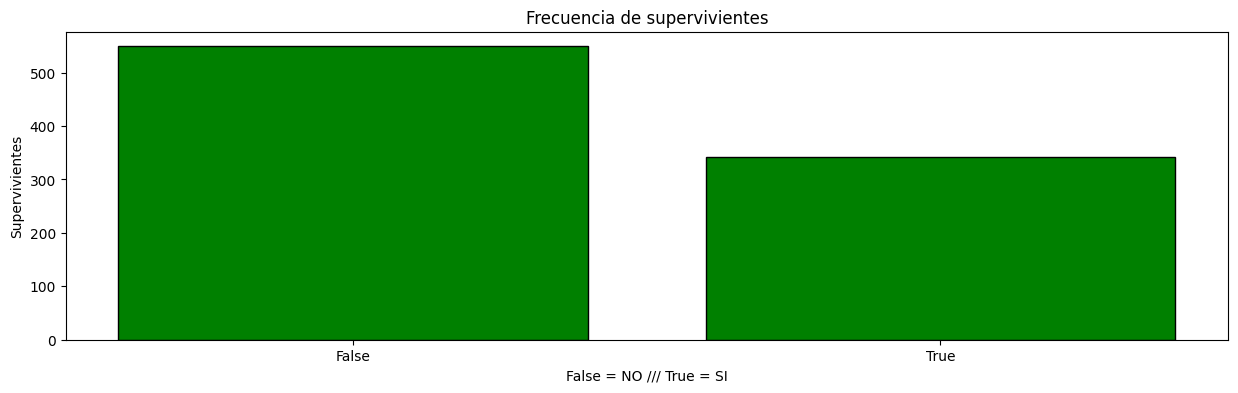

In [40]:
plt.figure(figsize=(15, 4))
plt.bar(df_survived.index, df_survived["Frecuencia Absoluta"], color='green', edgecolor='black') # Primero las etiquetas (en este caso el nombre de los departamentos que considero), luego los valores
plt.title('Frecuencia de supervivientes')
plt.xlabel('False = NO /// True = SI')
plt.ylabel('Supervivientes')
plt.show()

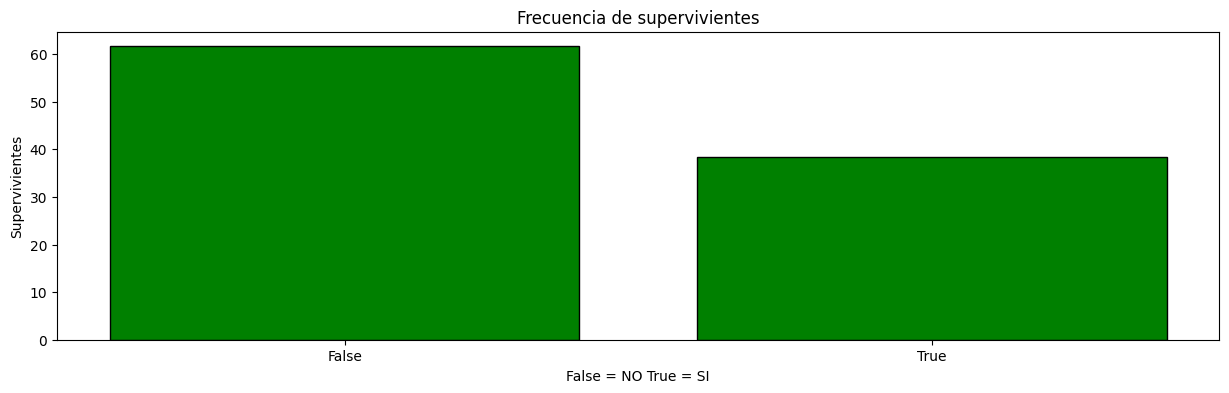

In [39]:
plt.figure(figsize=(15, 4))
plt.bar(df_survived.index, df_survived["Frecuencia Relativa"], color='green', edgecolor='black') # Primero las etiquetas (en este caso el nombre de los departamentos que considero), luego los valores
plt.title('Frecuencia de supervivientes')
plt.xlabel("False = NO True = SI")
plt.ylabel('Supervivientes')
plt.show()

Podemos observar que el numero de supervivientes es inferior al de fallecidos.


In [15]:
df_who = frecuencias(df_titanic, "who")
df_who

,Frecuencia Absoluta,Frecuencia Relativa
who,,
man,537,60.269360
woman,271,30.415264
child,83,9.315376


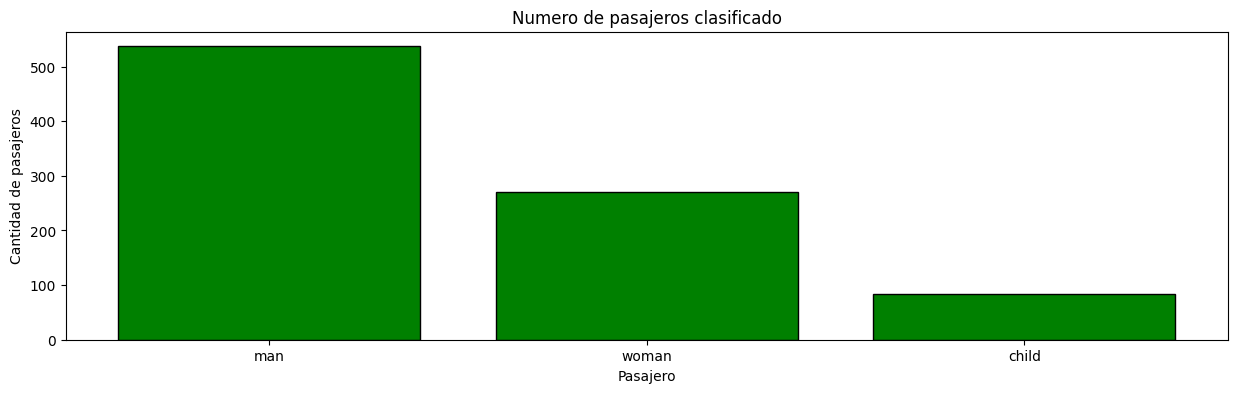

In [42]:
plt.figure(figsize=(15, 4))
plt.bar(df_who.index, df_who["Frecuencia Absoluta"], color='green', edgecolor='black') # Primero las etiquetas (en este caso el nombre de los departamentos que considero), luego los valores
plt.title('Numero de pasajeros clasificado')
plt.xlabel('Pasajero')
plt.ylabel('Cantidad de pasajeros')
plt.show()

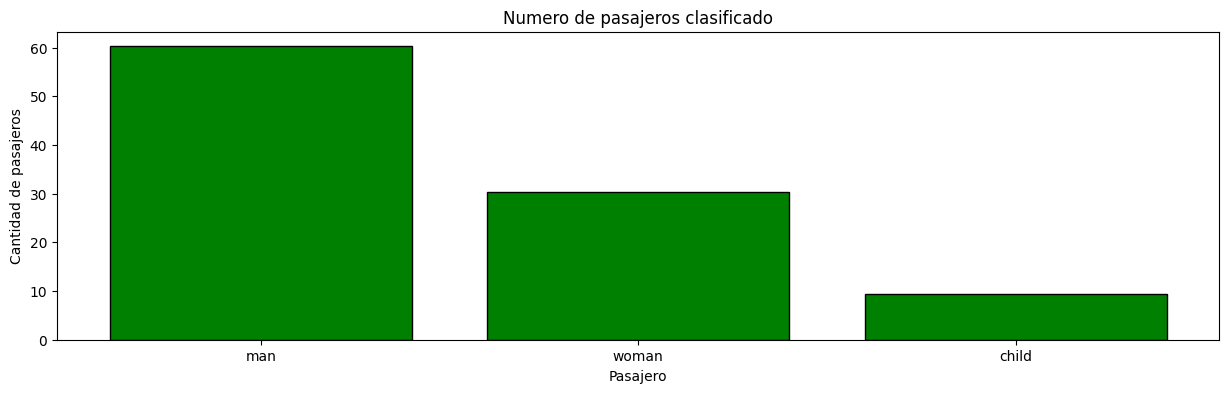

In [43]:
plt.figure(figsize=(15, 4))
plt.bar(df_who.index, df_who["Frecuencia Relativa"], color='green', edgecolor='black') # Primero las etiquetas (en este caso el nombre de los departamentos que considero), luego los valores
plt.title('Numero de pasajeros clasificado')
plt.xlabel('Pasajero')
plt.ylabel('Cantidad de pasajeros')
plt.show()

Se puede observar como la mayoria de pasajeros del titanic eran hombres (practicamente el doble que de mujeres).
Los niños no llegaban al 10% del total de pasajeros

In [19]:
df_class = frecuencias(df_titanic, "class")
df_class

,Frecuencia Absoluta,Frecuencia Relativa
class,,
Third,491,55.106622
First,216,24.242424
Second,184,20.650954


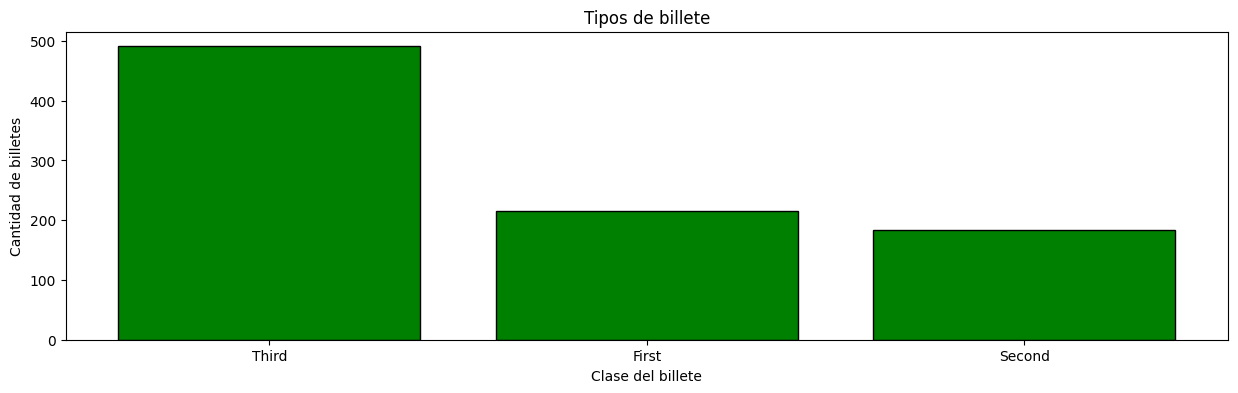

In [45]:
plt.figure(figsize=(15, 4))
plt.bar(df_class.index, df_class["Frecuencia Absoluta"], color='green', edgecolor='black') # Primero las etiquetas (en este caso el nombre de los departamentos que considero), luego los valores
plt.title('Tipos de billete')
plt.xlabel('Clase del billete')
plt.ylabel('Cantidad de billetes')
plt.show()

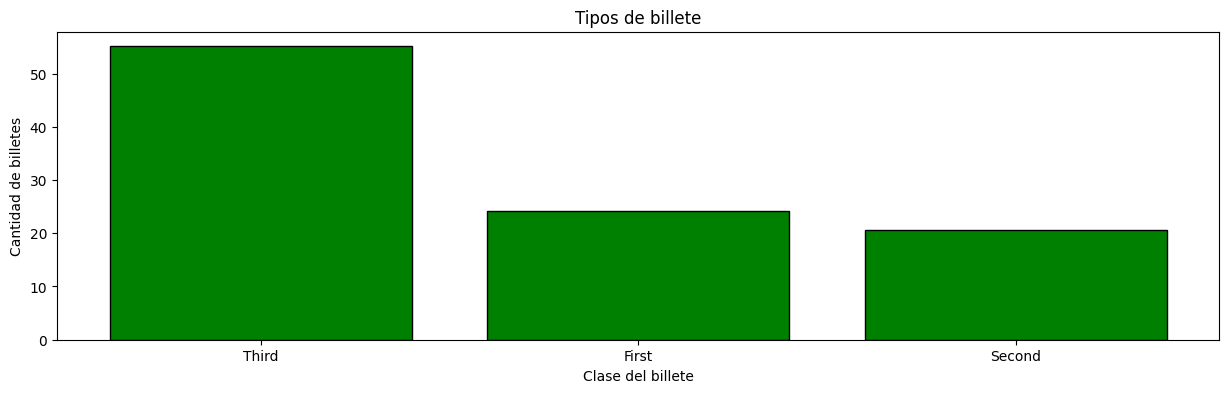

In [46]:
plt.figure(figsize=(15, 4))
plt.bar(df_class.index, df_class["Frecuencia Relativa"], color='green', edgecolor='black') # Primero las etiquetas (en este caso el nombre de los departamentos que considero), luego los valores
plt.title('Tipos de billete')
plt.xlabel('Clase del billete')
plt.ylabel('Cantidad de billetes')
plt.show()

Aquí se observa como la mayoría de billetes eran de tercera clase, y extrañamente, el numero de billetes de primera clase superó a los de segunda clase

In [20]:
df_embarked = frecuencias(df_titanic, "embarked")
df_embarked

,Frecuencia Absoluta,Frecuencia Relativa
embarked,,
Southampton,644,72.440945
Cherbourg,168,18.897638
Queenstown,77,8.661417


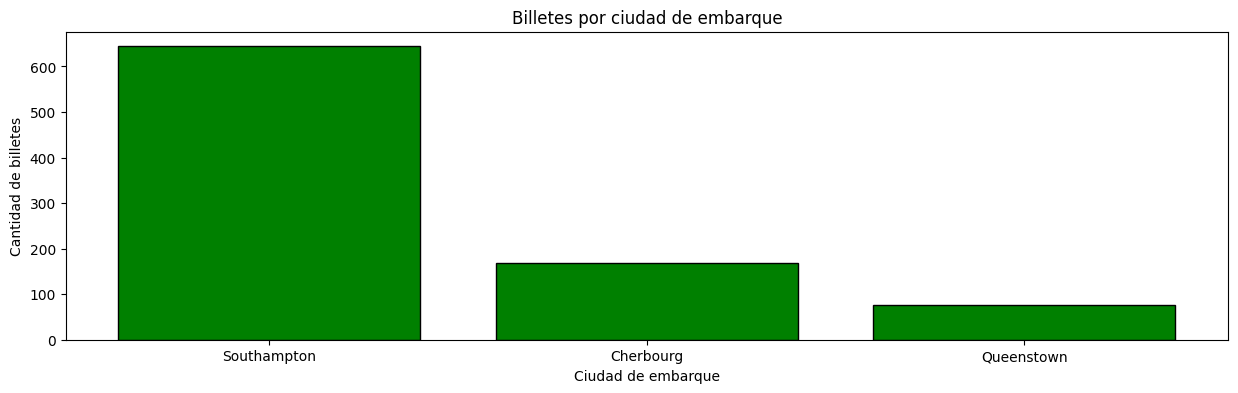

In [48]:
plt.figure(figsize=(15, 4))
plt.bar(df_embarked.index, df_embarked["Frecuencia Absoluta"], color='green', edgecolor='black') # Primero las etiquetas (en este caso el nombre de los departamentos que considero), luego los valores
plt.title('Billetes por ciudad de embarque')
plt.xlabel('Ciudad de embarque')
plt.ylabel('Cantidad de billetes')
plt.show()

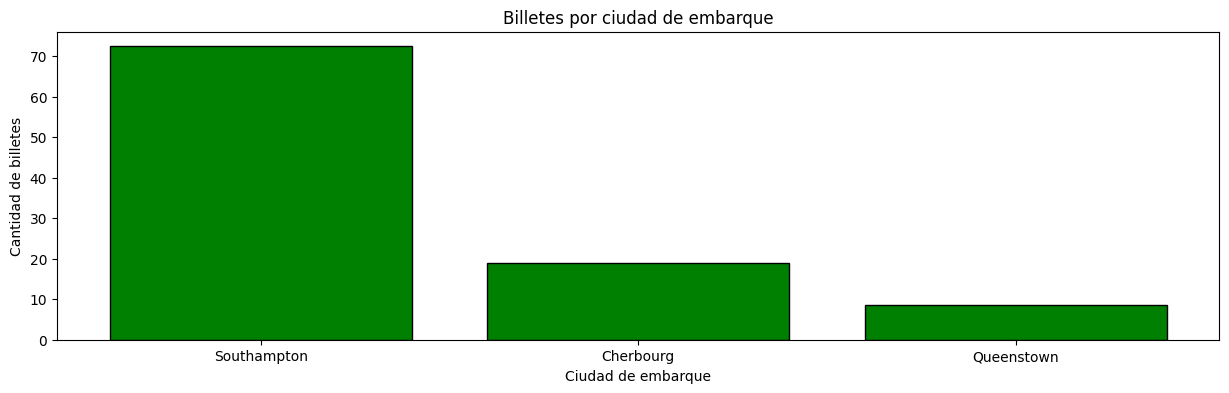

In [49]:
plt.figure(figsize=(15, 4))
plt.bar(df_embarked.index, df_embarked["Frecuencia Relativa"], color='green', edgecolor='black') # Primero las etiquetas (en este caso el nombre de los departamentos que considero), luego los valores
plt.title('Billetes por ciudad de embarque')
plt.xlabel('Ciudad de embarque')
plt.ylabel('Cantidad de billetes')
plt.show()

En este grafico, se observa como la mayoría de pasajeros (72,44%) embarcó desde southampton frente a una minoría desde Cherbourg (casi 19%) y muchos menos desde queenstown (menos del 9%)

In [59]:
df_alone = frecuencias(df_titanic, "alone")
df_alone

,Frecuencia Absoluta,Frecuencia Relativa
alone,,
True,537,60.26936
False,354,39.73064


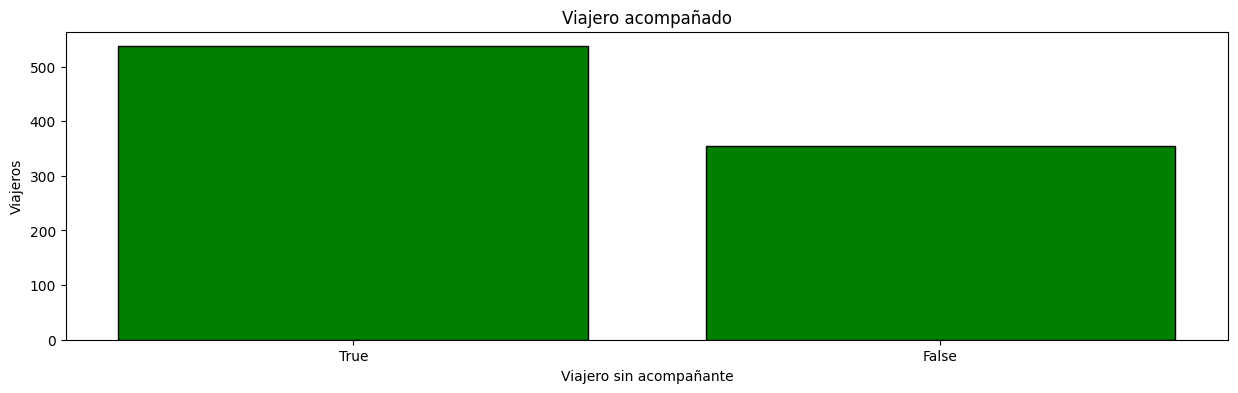

In [67]:
plt.figure(figsize=(15, 4))
plt.bar(df_alone.index, df_alone["Frecuencia Absoluta"], color='green', edgecolor='black') # Primero las etiquetas (en este caso el nombre de los departamentos que considero), luego los valores
plt.title('Viajero acompañado')
plt.xlabel('Viajero sin acompañante')
plt.ylabel('Viajeros')
plt.show()

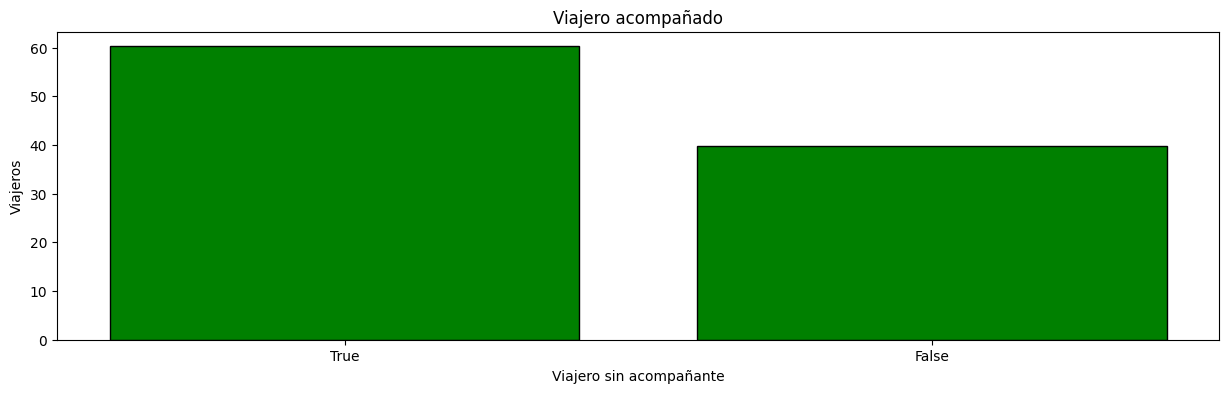

In [66]:
plt.figure(figsize=(15, 4))
plt.bar(df_alone.index, df_alone["Frecuencia Relativa"], color='green', edgecolor='black') # Primero las etiquetas (en este caso el nombre de los departamentos que considero), luego los valores
plt.title('Viajero acompañado')
plt.xlabel('Viajero sin acompañante')
plt.ylabel('Viajeros')
plt.show()

Se puede apreciar que la mayoría de pasajeros, en torno a 2/3, viajaron solos

In [74]:
categoricas = ["alive","who","class","embarked","alone","sex"]
numericas = ["age","fare"]

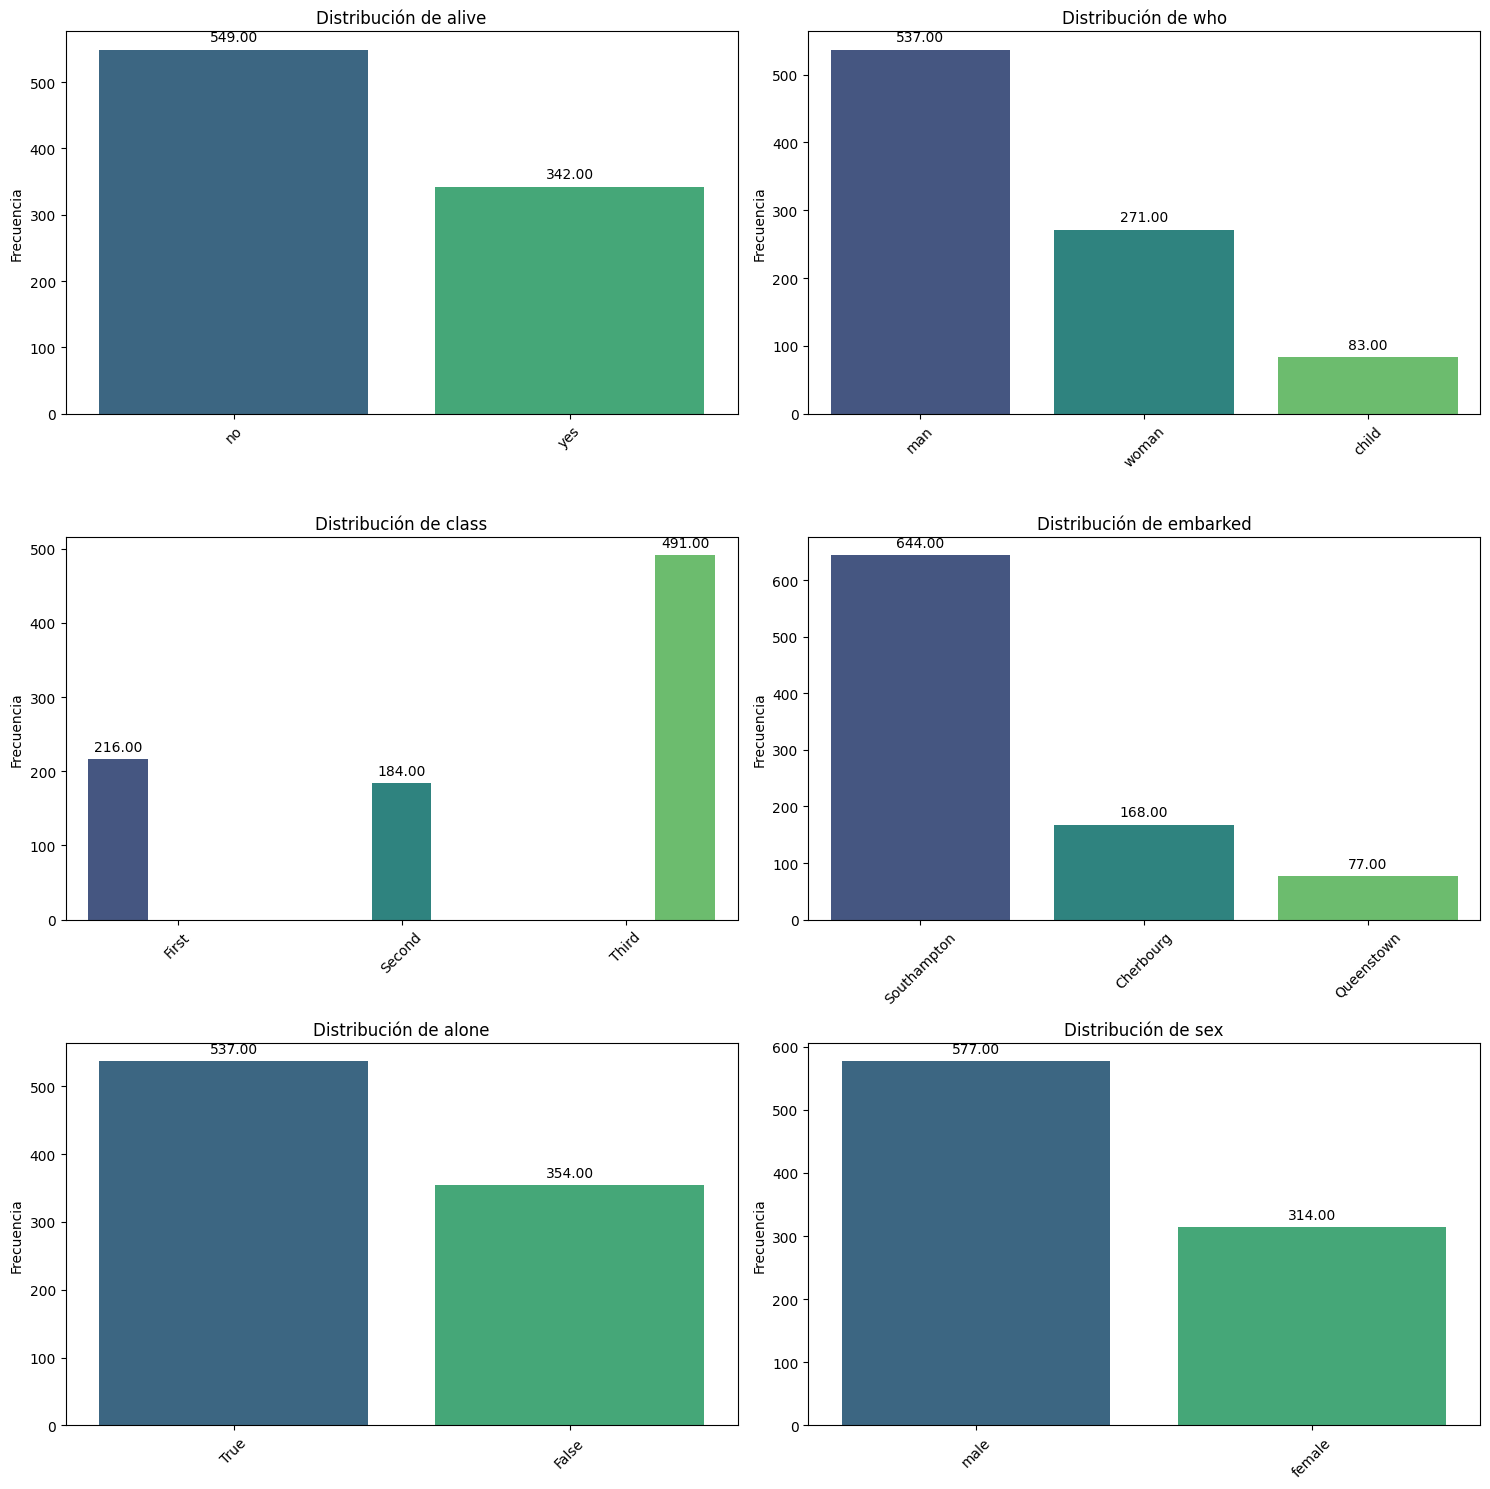

In [75]:
pinta_distribucion_categoricas(df_titanic, categoricas, mostrar_valores= True)

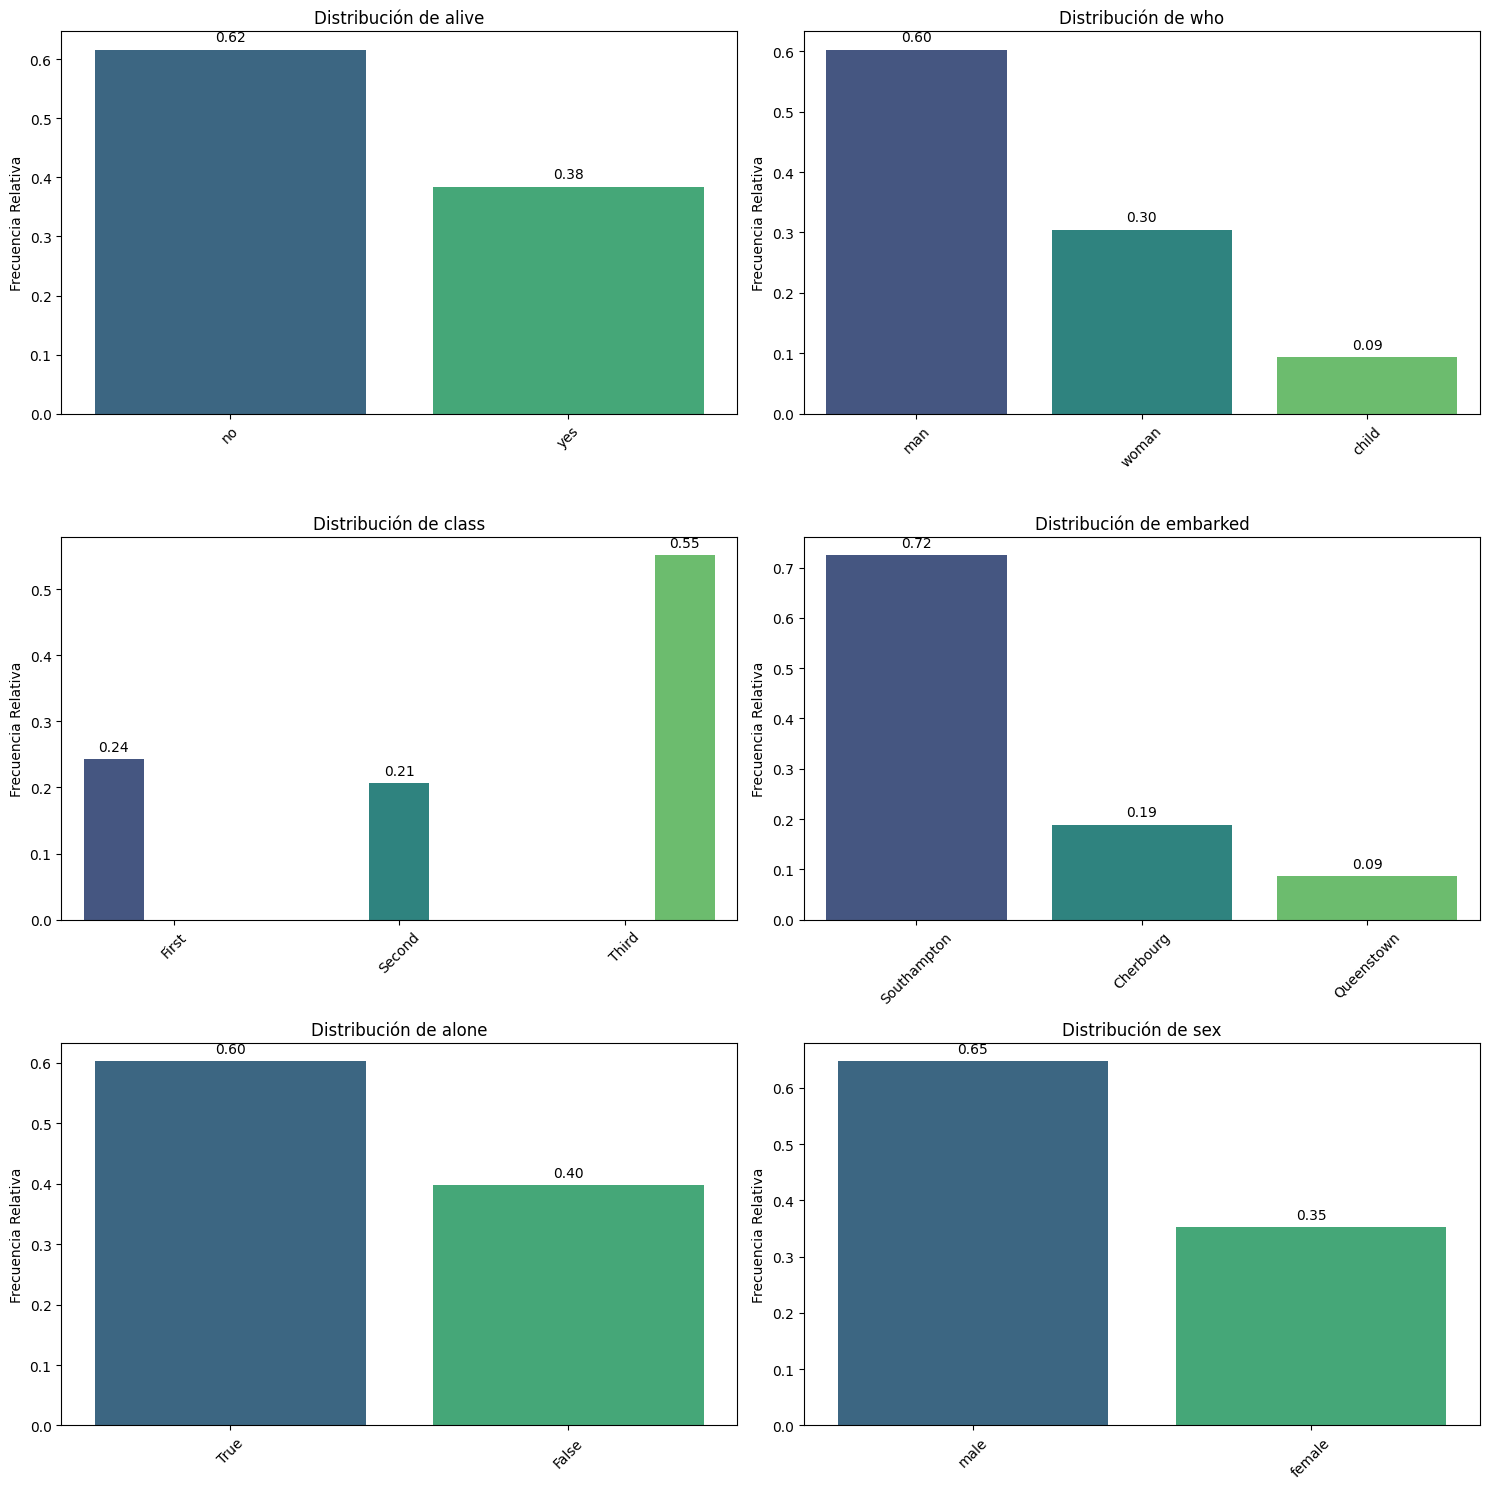

In [76]:
pinta_distribucion_categoricas(df_titanic, categoricas, relativa= True, mostrar_valores= True)

### #2.2 Numéricas

In [ ]:
# fare, age

In [77]:
df_titanic[["fare", "age"]].describe()

,fare,age
count,891.000000,714.000000
mean,32.204208,29.699118
std,49.693429,14.526497
min,0.000000,0.420000
25%,7.910400,20.125000
50%,14.454200,28.000000
75%,31.000000,38.000000
max,512.329200,80.000000


In [78]:
def get_CV(df, columna):
    columna = [columna] if type(columna) == str else columna
    return df[columna].describe().T["std"]/df[columna].describe().T["mean"] * 100

In [79]:
get_CV(df_titanic, "fare")

fare    154.307253
dtype: float64

In [80]:
get_CV(df_titanic, "age")

age    48.912219
dtype: float64

(2, 2)


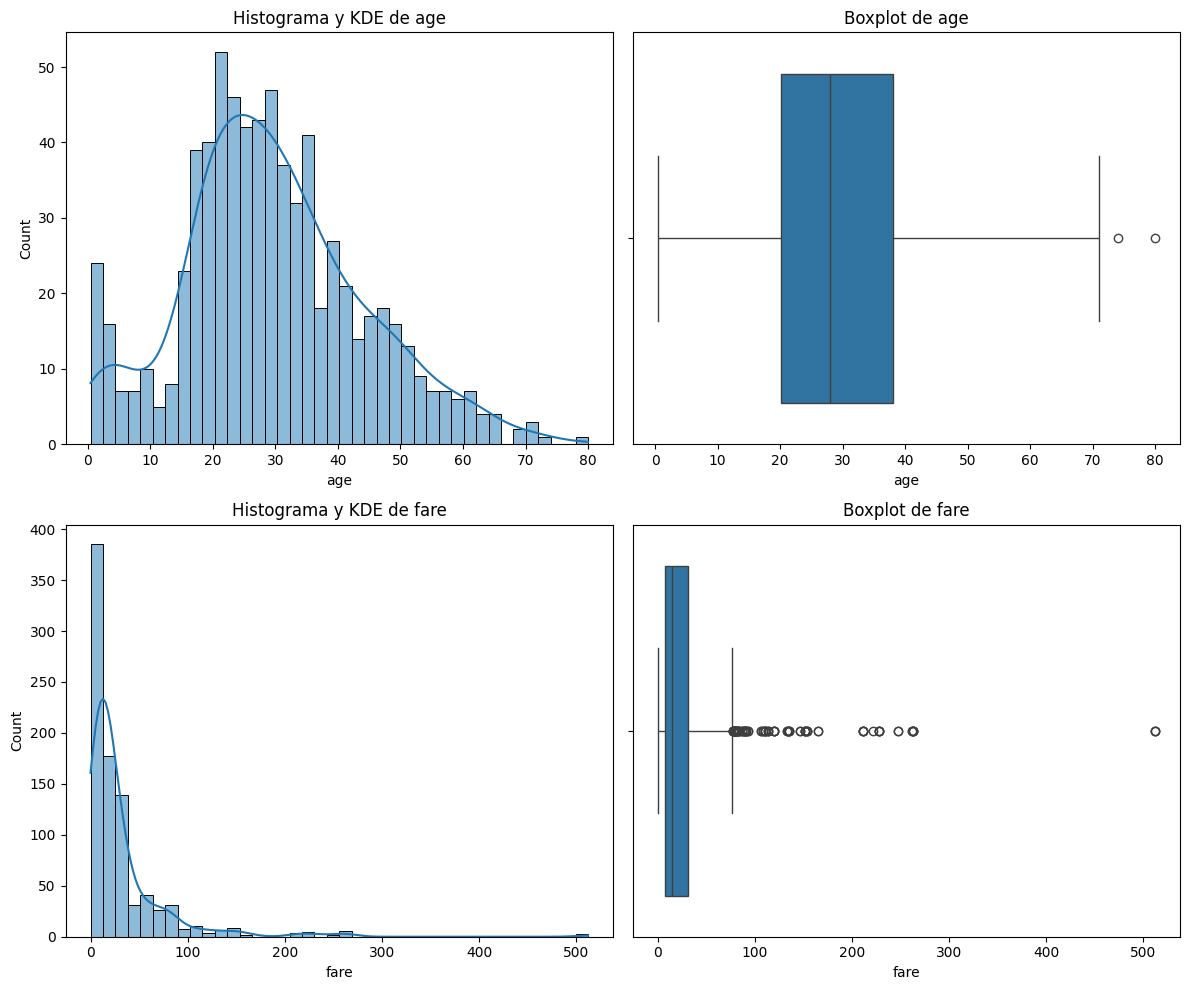

In [81]:
plot_combined_graphs(df_titanic, ["age", "fare"], whisker_width=2, bins= 40)

Observamos que la mayoría de los viajeros se concentran en el rango de edad de 20-30, con algunos outliers correspondientes a los bebes y los ancianos. Aunque en el caso de los bebes suponen una cantidad significativa.

Respecto al precio del billete, sigue una curva previsible en la que se aprecia que la mayoría de los billetes tuvieron un precio bajo, mientras que, a medida que asciende el precio, disminuye el numero de compras.